In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys

PDM_DIR = os.environ.get('PDM_DIR', '../../../PDM')
sys.path.append(f'{PDM_DIR}/src')
import verbatim_eval.controlled_expr as _ce
import verbatim_eval.rouge_ttr as _rt
import verbatim_eval.utils as _ut
sys.modules['controlled_expr'] = _ce  # needed for pickle deserialization
sys.modules['rouge_ttr'] = _rt
sys.modules['utils'] = _ut

sys.path.insert(0, '../..')
from attn_bench.plotting import model_registry
from attn_bench.plotting.data_loading import load_mem_results_scores_grid, load_mem_results_scores_grid_by_name
from attn_bench.plotting.heatmap import plot_models_heatmap_panel, plot_heatmap_per_model_panel

# Backend comparison

Megatron vs. HF inference backend, same checkpoint -- sanity-checks that the two agree
before trusting HF-backend-only sweeps elsewhere (e.g. `swa_variants.ipynb`'s prefix and
diagonal panels). Uses `model_registry.model_folder(key, 'hf')` +
`load_mem_results_scores_grid_by_name` to load both backends of one checkpoint as
explicit side-by-side labels (not the priority-fallback `backend=[...]` used elsewhere).


## Comparing scf1-trained checkpoint + inference backends (full attention only)

`full-scf1` is trained AND inferred with `--rope-scaling-factor 1` -- unlike the section above, this isn't an isolated RoPE-scaling ablation of `full-scf8`, it's a separate training run. Besides `--rope-scaling-factor 1` (vs 8) and the resulting `--max-position-embeddings 8192` (vs 131072), it also differs in micro/global batch size (MBS 3 vs 4, GBS 288 vs 336), TP size (1 vs 2, no `--sequence-parallel`), weight decay (0.1 vs 0.01), LR warmup iters (500 vs 2000), and total train-iters (18141 vs 15550) -- so any gap vs `full-scf8` below reflects the whole training-config diff, not RoPE scaling alone.

Also includes `full-scf1 (hf)`: the same `full-scf1` checkpoint run through the HF inference backend instead of Megatron, to check the two backends agree.

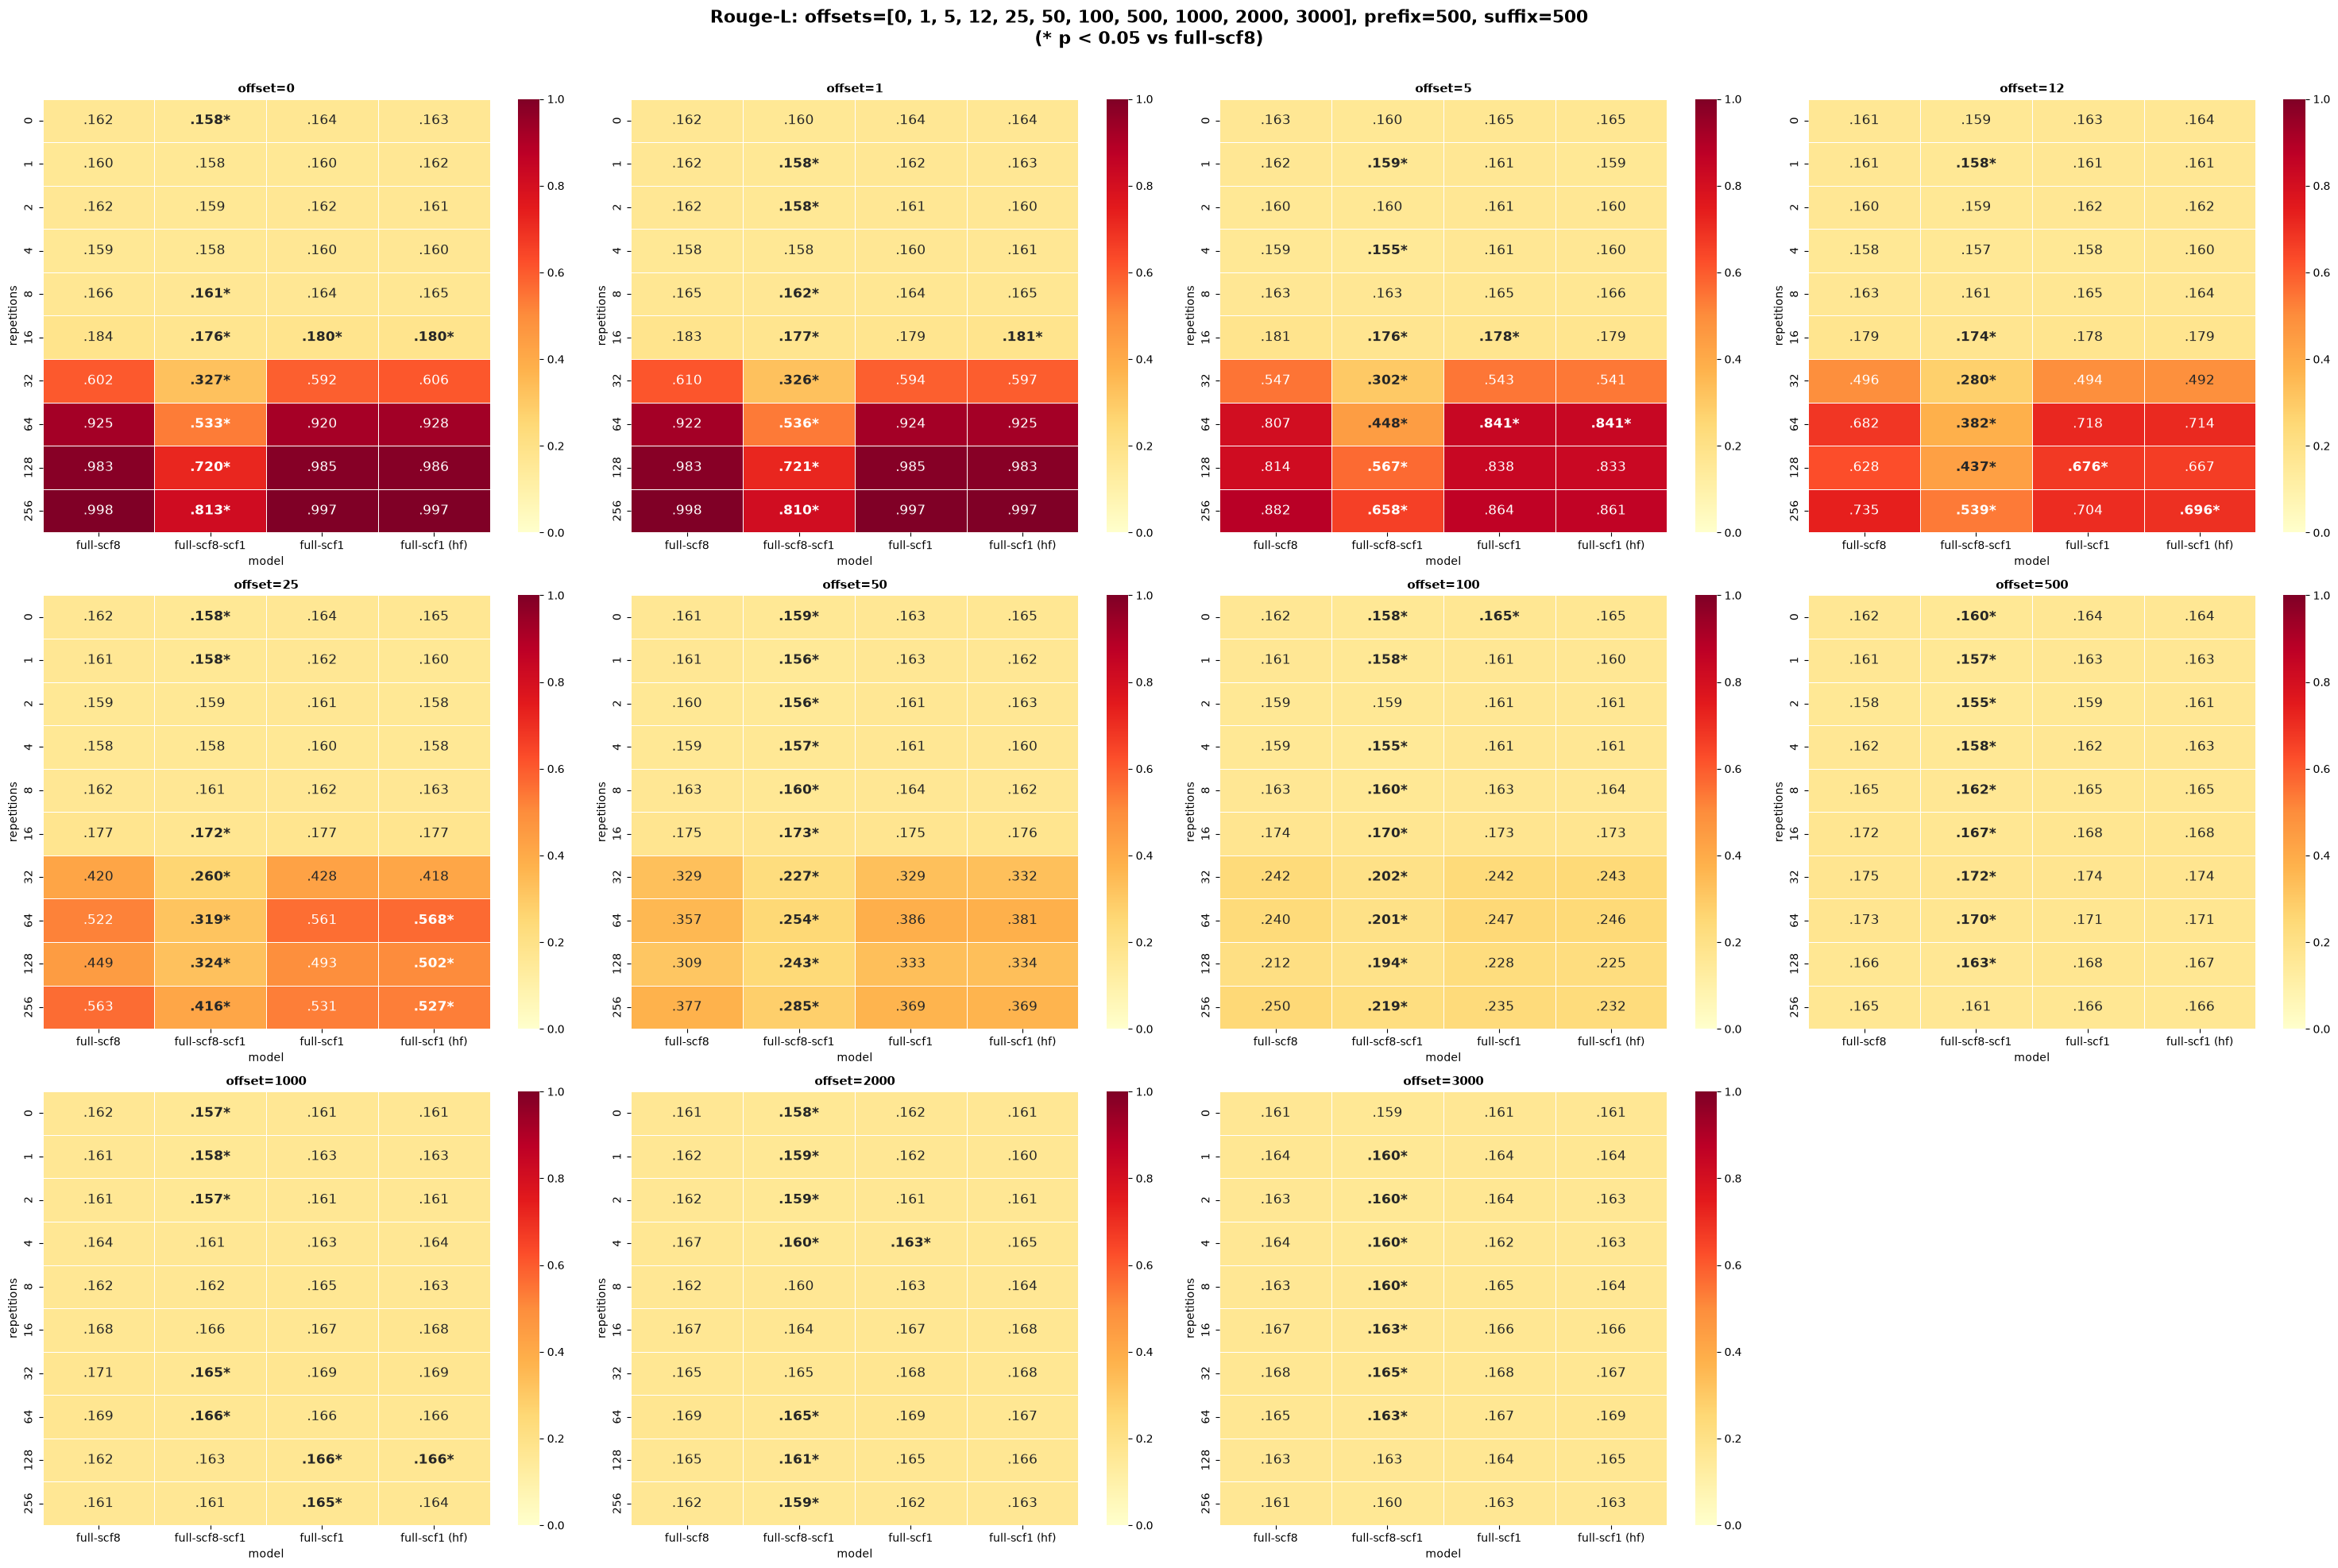

In [3]:
SCF1_LABELS = {
    'full-scf8': model_registry.MODELS['full-scf8'],
    'full-scf8-scf1': model_registry.MODELS['full-scf8-scf1'],
    'full-scf1': model_registry.MODELS['full-scf1'],
    'full-scf1 (hf)': model_registry.model_folder('full-scf1', 'hf'),
}
SCF1_OFFSETS = [0, 1, 5, 12, 25, 50, 100, 500, 1000, 2000, 3000]

scf1_results_grid = load_mem_results_scores_grid_by_name(
    SCF1_OFFSETS, [500], [500], SCF1_LABELS, results_base=model_registry.MEM_RESULTS_DIR
)

plot_models_heatmap_panel(
    scf1_results_grid, 'Rouge-L', panels='offset', values=SCF1_OFFSETS, fixed_prefix=500, fixed_suffix=500,
    reference='full-scf8', show_pvalues=False, models=list(SCF1_LABELS),
)